# AMADS Coding Notebooks

### Key Finding

How do we find the key for a music passage? This notebook tries to bring a
gentle introduction to key-finding.

---

**For:** Attached to the
[AMADS code library](https://github.com/music-computing/amads/) and
["Keeping Score" book](https://doi.org/10.5281/zenodo.14938027),
but open to all.

**Licence:** MIT.

**Colour key:**
- <font color='green'> Green is for a block of information.
- <font color='purple'> Purple is for an exercise.
- <font color='crimson'> Crimson is for the solution to the exercise above it.

In [39]:
import os

from amads.core.basics import Score
from amads.pitch.key.kkcc import kkcc
from amads.pitch.key.kkkey import kkkey
from amads.pitch.key.keysom import keysom
from amads.pitch.key.keysomdata import KeyProfileSOM
from amads.core.distribution import Distribution
from amads.core.pitch import CHROMATIC_NAMES

# code credit to Tai Nakamura for providing said example
C_MAJOR_SCALE_UP_SI_DOWN = [
    60,
    62,
    64,
    65,
    67,
    69,
    71,
    72,
    71,
    69,
    67,
    65,
    64,
    62,
    60,
]

C_SCALE_MELODY_SCORE = Score.from_melody(C_MAJOR_SCALE_UP_SI_DOWN)

# chromatic names for both major and minor keys
CHROMATIC_NAMES_FULL = CHROMATIC_NAMES + [txt.lower() for txt in CHROMATIC_NAMES]

## <font color='Green'> Some definitions and terminology

To preface this section, let us define some terminology here.

1. A key profile is an information representation that describes features which
can be used by an  accompanying extraction algorithm to extract a musical
passage's key and pitch characteristics.
2. A chromatic key is the starting pitch on a traditional western scale for the
given key.
3. A chromatic index is the index to a pitch on the chromatic scale beginning at
C.
4. We will also use the terms musical passage, passage, and score interchangeably
to mean the same thing: a passage of music represented symbolically by a score
as specified at [amads/core/basics.py](../amads/core/basics.py).

## <font color='Green'> Early work (Key Profile Matching)

### <font color='Green'>How are the Krumhansl & Kessler (1982) key profiles obtained?

In Krumhansl & Kessler (1982), the internal representation for key profile is
a pitch-class distribution. In addition, they introduced the concept of a
probe-tone rating, which forms the basis (and smallest unit of information) for
the aforementioned representation.

Researchers obtained these key profiles through a series of experiments.
The test subjects, whom were trained musicians, were given the following tasks
per experiment (in order):
1. Hear a context sequence, consisting of an incomplete major or minor scale
or a chord cadence.
2. The next chromatic scale pitch (with respect to the previous trial)
3. Assign a probe-tone rating (between 1-10)

This experiment is repeated until all the pitches in the chromatic scale have
been played in step 2.

You can view the Krumhansl & Kessler key profile along with many others included
in this library at [amads/pitch/key/profiles.py](../amads/pitch/key/profiles.py).

### <font color='Green'> First algorithm leveraging key profiles

We introduce the classic Krumhansl & Schmuckler key-finding algorithm 
(Krumhansl, 1990).
To find the key of a passage, this algorithm matches a collection of key
profiles to the profile of a given passage with the following requirements:
1. Each profile is represented as a pitch-class distribution, or a sequence of
12 weights, weighing each of the pitches in the western music chromatic scale.
2. A key profile "matches" with the profile of the passage by taking the
correlation of the key profile with the profile of the passage.
3. Each key represented as a pitch-class distribution, against the pitch-class
distribution (represented as a desired pitch-class distribution).

### <font color='Green'> Introduction to relevant library features

Here is a simple c-diatonic scale played up and down being initialized and
key-profile matched with the algorithm described above.

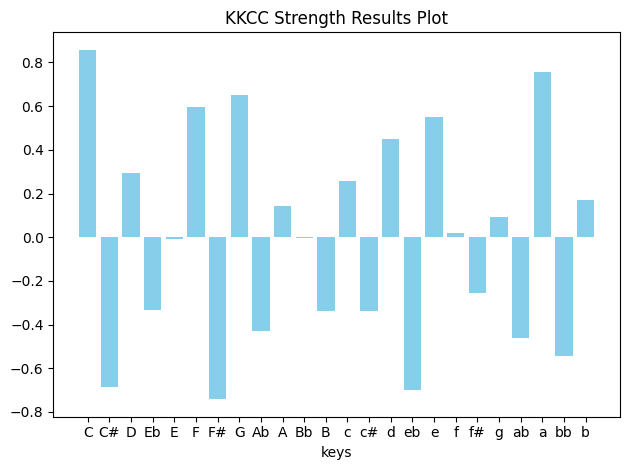

In [40]:
coefs = kkcc(C_SCALE_MELODY_SCORE)
# plot into a distribution
plotdist = Distribution(name="KKCC Strength Results Plot",
                        data=coefs,
                        distribution_type="Example Plot Type for kkcc",
                        dimensions=[24],
                        x_categories=CHROMATIC_NAMES_FULL,
                        x_label="keys",
                        y_categories=None,
                        y_label=None)

# semicolon (;) used to suppress jupyter showing the return value of last line
plotdist.plot();

Under the hood, unlike the matlab implementation, we use a more generalized
version of kkcc called key_cc, which implements the aforementioned algorithm but
can take an arbitrary collection of well-identified (can be uniquely identified)
key profiles.

To obtain the most likely key the passage is in, we can simply run kkkey,
which returns the profile identifier and chromatic index for the
key profile of the largest value when running key_cc as follows:

In [41]:
# in this case, kkkey's default value leverages Krumhansl-Kessler (1982), which
# happen to be labelled as "major" and "minor" profiles to correspond to their
# actual situation.
pitch_profile_name, chromatic_index = kkkey(C_SCALE_MELODY_SCORE)

print(CHROMATIC_NAMES[chromatic_index], pitch_profile_name)

C major


## <font color='Green'> Self-Organizing Map (SOM) representation for key-finding

A related concept to the previous key-finding algorithm is to train a
self-organizing map. By their own nature, SOMs have a few advantages:
1. they tend to learn and internalize the structural features within the key
profiles.
2. they are designed to visualize and explain structural elements of inputs.
3. a SOM can be trained on the key profiles to extract and identify similar key
features in musical passages.

The design decisions used in training are boring and nitpicky, and there may be
more mathematically sound training choices.
However, the authors of this notebook has found success basing the SOM off of
the representations specified by the gestalt interpretation of melodies and
melodic boundaries in Tenney & Polansky (1980).
Namely, (1) the key profiles follows the circle-of-fifths key torus and (2)
learning decay rate for the SOM mirrors human learning rate of domain knowledge.

The rest of the knowledge for SOMs themselves can be found on wikipedia
[here](https://en.wikipedia.org/wiki/Self-organizing_map)

### <font color='Green'> Introduction to relevant library features

The main file for key-profile based SOMs in this library are located
at [amads/pitch/key/keysomdata.py](../amads/pitch/key/keysomdata.py).

However, we recommend starting with the keysom wrapper (also a port of keysom
from miditoolbox). This wrapper leverages the pretrained SOM included with this 
library, and outputs a preset visualization of the key characteristics of a
score.

More details of the pretrained SOM can be found in keysomdata.py

Below, we provide a simple example:

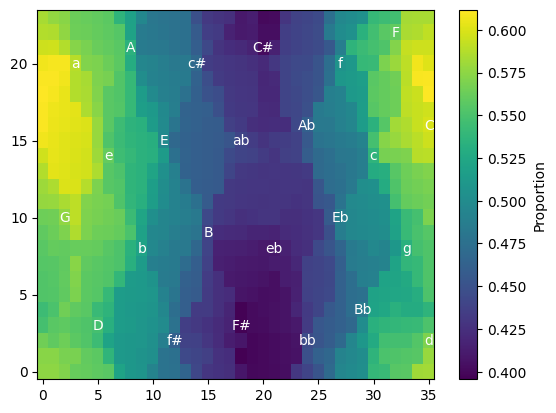

(array([[0.57494083, 0.57469419, 0.57048924, 0.56167418, 0.5604424 ,
         0.55851286, 0.55664348, 0.52071302, 0.5100985 , 0.50745133,
         0.49251005, 0.47810742, 0.47654545, 0.46493271, 0.44144132,
         0.43016532, 0.42741703, 0.42473106, 0.40862806, 0.40045071,
         0.40082308, 0.40211388, 0.40355712, 0.43064391, 0.43958634,
         0.45204435, 0.47060775, 0.49468458, 0.49868629, 0.50279025,
         0.53970942, 0.54243924, 0.55526608, 0.5568303 , 0.58066721,
         0.58184019],
        [0.57332282, 0.57310128, 0.56849893, 0.56817742, 0.55947024,
         0.55765502, 0.53701064, 0.51259744, 0.50975099, 0.50673878,
         0.50357505, 0.47784459, 0.47575506, 0.44309481, 0.44062306,
         0.43617608, 0.42658707, 0.42378256, 0.3955635 , 0.39966521,
         0.40096251, 0.40249995, 0.40419472, 0.40651886, 0.44835658,
         0.46300642, 0.46796767, 0.49262088, 0.49664712, 0.50194636,
         0.53646299, 0.55017786, 0.55261027, 0.55409541, 0.55577084,
         0.5

In [42]:
# Get the current working directory
# custom file path because jupyter seems a bit finnicky with regards to the
# file path../amads/pitch/key/KrumhanslKessler_SOM_data.npz
pretrained_SOM_path = os.path.join(
    "..",
    "amads",
    "pitch",
    "key",
    "KrumhanslKessler_SOM_data.npz"
)
test_SOM = KeyProfileSOM.from_trained_SOM(file_path = pretrained_SOM_path)

keysom(C_SCALE_MELODY_SCORE, test_SOM)